# Sự Kết Hợp Tối Thượng: 165 Tính năng Giao Dịch Gốc + Tính chất Đồ Thị (Graph Features)

Notebook này là trạm kiểm định cuối cùng và mạnh mẽ nhất cho dòng Học Máy Truyền Thống. Chúng ta sẽ hợp nhất cả đặc trưng tài sản (165 features gốc xuất sắc để tìm thủ thuật che giấu) cùng với cả đặc trưng topology (NetworkX Graph đánh giá quy mô đường dây).

Kết quả được kỳ vọng sẽ cao nhất trong toàn bộ giới ML (kèm rủi ro Dimensionality) và có thể đánh bại một số mô hình Graph Neural Networks nếu tuning chuẩn thông số!

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import networkx as nx
import time
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
import lightgbm as lgb
import xgboost as xgb
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score


## 1. Nạp cơ sở dữ liệu Toàn Phân
Lấy toàn bộ cột trong `elliptic_txs_features.csv`

In [3]:
print("📥 Đang tải dữ liệu gốc...")
df_edges = pd.read_csv('data/elliptic/elliptic_txs_edgelist.csv')
df_classes = pd.read_csv('data/elliptic/elliptic_txs_classes.csv')

# Nạp toàn bộ tính năng và đặt tên lại 165 cột ẩn danh
df_features = pd.read_csv('data/elliptic/elliptic_txs_features.csv', header=None)
original_feature_cols = [f'feature_{i}' for i in range(1, 166)]
df_features.columns = ['txId', 'time_step'] + original_feature_cols

print(f"Xong! Tìm thấy {len(df_edges)} kết nối (edges).")

📥 Đang tải dữ liệu gốc...
Xong! Tìm thấy 234355 kết nối (edges).


## 2. Dựng Đồ Thị & Tính Tích Lũy NetworkX
Quá trình này vẫn sẽ mất vài phút.

In [4]:
start_time = time.time()

print("🕸️ Đang dựng Graph...")
G_dir = nx.from_pandas_edgelist(df_edges, 'txId1', 'txId2', create_using=nx.DiGraph())
G_undir = G_dir.to_undirected()

print("1/5 Đang tính In-Degree và Out-Degree...")
in_deg = dict(G_dir.in_degree())
out_deg = dict(G_dir.out_degree())

print("2/5 Đang tính PageRank Centrality...")
pr = nx.pagerank(G_dir, alpha=0.85)

print("3/5 Đang tính Clustering Coefficient...")
clustering = nx.clustering(G_undir)

print("4/5 Đang chạy HITS (Hubs & Authorities)...")
hubs, auth = nx.hits(G_dir, max_iter=100)

print("5/5 Tổng hợp thành DataFrame...")
nodes = list(G_dir.nodes())
features_list = [{
    'txId': n,
    'in_degree': in_deg.get(n, 0),
    'out_degree': out_deg.get(n, 0),
    'pagerank': pr.get(n, 0),
    'clustering': clustering.get(n, 0),
    'hub_score': hubs.get(n, 0),
    'auth_score': auth.get(n, 0)
} for n in nodes]

df_graph = pd.DataFrame(features_list)

print(f"✅ Khai phá đồ thị hoàn tất trong {time.time() - start_time:.1f} giây!")

🕸️ Đang dựng Graph...
1/5 Đang tính In-Degree và Out-Degree...
2/5 Đang tính PageRank Centrality...
3/5 Đang tính Clustering Coefficient...
4/5 Đang chạy HITS (Hubs & Authorities)...
5/5 Tổng hợp thành DataFrame...
✅ Khai phá đồ thị hoàn tất trong 6.2 giây!


## 3. Mix Data: Nối thông tin Đồ thị vào Tập Dữ Liệu Bảng Tổng
Mở rộng bảng ra và đảm bảo Temporal Split <= 34.

In [5]:
# Ghép nhãn
df = pd.merge(df_features, df_classes, on='txId', how='left')

# Ghép thuộc tính liên kết Graph
df = pd.merge(df, df_graph, on='txId', how='left')
df.fillna(0, inplace=True)

# Tẩy node ẩn
df = df[df['class'] != 'unknown'].reset_index(drop=True)
df['class'] = df['class'].map({'1': 1, '2': 0})

# Phân hoạch Temporal Train/Test split
train_df = df[df['time_step'] <= 34]
test_df = df[df['time_step'] > 34]

# Lọc toàn bộ features: 165 features ẩn danh + 6 features hình học/vị trí mấu chốt
graph_feature_cols = ['in_degree', 'out_degree', 'pagerank', 'clustering', 'hub_score', 'auth_score']
all_feature_cols = original_feature_cols + graph_feature_cols

X_train = train_df[all_feature_cols]
y_train = train_df['class']

X_test = test_df[all_feature_cols]
y_test = test_df['class']

print(f"Số lượng Features đang có: {len(all_feature_cols)} chiều.")
print(f"Dữ liệu Train: {X_train.shape[0]} samples. Dữ liệu Test: {X_test.shape[0]} samples.")

Số lượng Features đang có: 171 chiều.
Dữ liệu Train: 29894 samples. Dữ liệu Test: 16670 samples.


## 4. Báo Cáo Huấn Khảo Sát 7 Models Mở Rộng

In [6]:
models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    "KNN": KNeighborsClassifier(n_neighbors=5, n_jobs=-1),
    "Naïve Bayes": GaussianNB(),
    "Bagging": BaggingClassifier(random_state=42, n_jobs=-1),
    "LightGBM": lgb.LGBMClassifier(random_state=42, n_jobs=-1, verbose=-1),
    "XGBoost": xgb.XGBClassifier(random_state=42, n_jobs=-1, eval_metric='logloss')
}

results = []
print("🚀 Bắt đầu huấn luyện...\n" + "-"*40)

for name, model in models.items():
    print(f"Đang chạy: {name}...")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    
    results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-Score": f1
    })
    
df_results = pd.DataFrame(results).sort_values(by="F1-Score", ascending=False).reset_index(drop=True)
display(df_results)

🚀 Bắt đầu huấn luyện...
----------------------------------------
Đang chạy: Decision Tree...
Đang chạy: Random Forest...
Đang chạy: KNN...
Đang chạy: Naïve Bayes...
Đang chạy: Bagging...
Đang chạy: LightGBM...
Đang chạy: XGBoost...


,Model,Accuracy,Precision,Recall,F1-Score
0,Random Forest,0.980384,0.967822,0.722068,0.827076
1,LightGBM,0.977624,0.916667,0.721145,0.807235
2,XGBoost,0.976605,0.892412,0.727608,0.801628
3,Bagging,0.970726,0.812829,0.713758,0.760079
4,KNN,0.944391,0.563312,0.640813,0.599568
5,Decision Tree,0.916137,0.420414,0.768236,0.543436
6,Naïve Bayes,0.701920,0.164537,0.879963,0.277236


## 5. Phân tích Feature Importance Nhỏ Hẹp (Top 20 Thuộc Tính Hàng Đầu)
Bởi vì chúng ta có lượng kích cỡ cột lên tới 171 Columns, ta sẽ chỉ vinh danh 20 biến số có ảnh hưởng sâu sắc nhất từ góc độ của thuật toán có sức mạnh tối hậu (XGBoost & Random Forest)

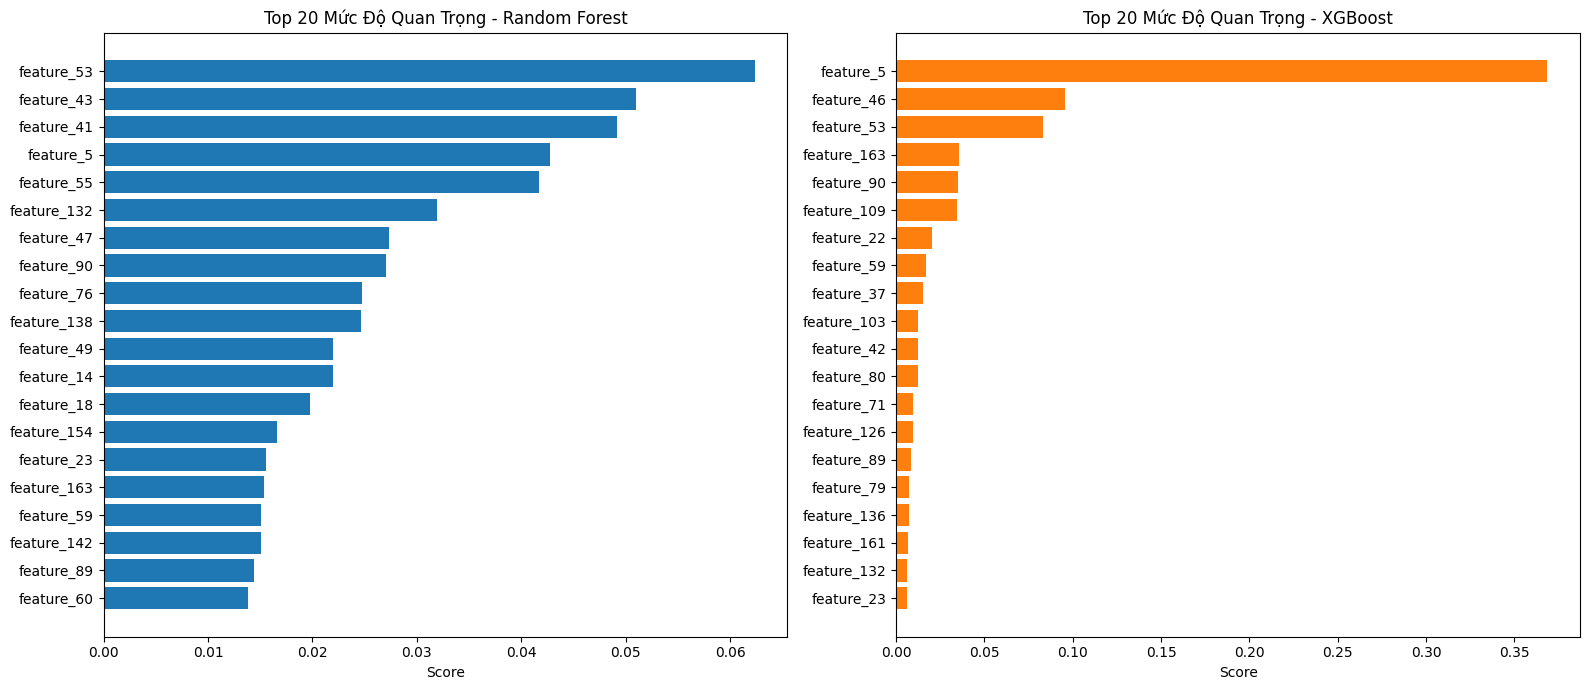

In [7]:
rf_model = models["Random Forest"]
xgb_model = models["XGBoost"]
top_n = 20

fig, ax = plt.subplots(1, 2, figsize=(16, 7))

# Biểu đồ Random Forest (Sếp theo F.I đảo chiều lấy 20 rồi lật ngược để vẽ)
rf_importances = pd.Series(rf_model.feature_importances_, index=all_feature_cols).sort_values(ascending=False).head(top_n).sort_values(ascending=True)
ax[0].barh(rf_importances.index, rf_importances.values, color='#1f77b4')
ax[0].set_title(f'Top {top_n} Mức Độ Quan Trọng - Random Forest')
ax[0].set_xlabel('Score')

# Biểu đồ XGBoost
xgb_importances = pd.Series(xgb_model.feature_importances_, index=all_feature_cols).sort_values(ascending=False).head(top_n).sort_values(ascending=True)
ax[1].barh(xgb_importances.index, xgb_importances.values, color='#ff7f0e')
ax[1].set_title(f'Top {top_n} Mức Độ Quan Trọng - XGBoost')
ax[1].set_xlabel('Score')

plt.tight_layout()
plt.show()